In [154]:
%load_ext autoreload
%autoreload 2
from auspex.instruments import SR865
from rensci import RenSciDriver
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from datetime import datetime
import os
import array

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [155]:
PIEZO_HOST = "172.31.255.99"
PIEZO_PORT = 6002

lockin = SR865()
lockin.connect('TCPIP0::172.31.255.252')

print(f"Connected to {lockin.name} \n\n X= {lockin.x}, Y = {lockin.y}")

xyz = RenSciDriver(PIEZO_HOST, PIEZO_PORT)
xyz.connect()


Connected to SR865 Lockin Amplifier 

 X= 2.0518427846e-05, Y = 6.2721745053e-05
Connected to 172.31.255.99:6002


In [156]:
def refocus(channel=1, nsteps=200, stepsize=10, lockin_time_constant=0.03):
    x=[]
    r=[]
    xyz.goStepsReverse(channel, int(nsteps/2)*stepsize)
    for i in range(nsteps):
        time.sleep(lockin_time_constant * 5)  # Wait for lock-in to stabilize
        r.append(lockin.r)
        x.append(xyz.getPosition(channel))
        xyz.goStepsForward(channel, stepsize)
    r = np.array(r)
    x = np.array(x)
    xyz.wait_open_loop_done()
    return x[np.argmax(r)], x,r
    
def getStepDistance(channel=2, stepSize=10, nsteps=10):
    step = []
    distance = []

    # Record the starting position
    startPosition = xyz.getPosition(channel)

    if channel == 3:
        for i in range(nsteps):
            xyz.goStepsReverse(channel, stepSize)
            step.append((i + 1) * stepSize)
            distance.append(xyz.getPosition(channel) - startPosition)
    else:
        for i in range(nsteps):
            xyz.goStepsForward(channel, stepSize)
            step.append((i + 1) * stepSize)
            distance.append(xyz.getPosition(channel) - startPosition)

    # Linear fit: distance = slope * step + intercept
    coeffs = np.polyfit(step, distance, 1)
    slope = coeffs[0]  # microns per step unit

    # Distance per single step (stepSize=1)
    distancePerStep = abs(slope)  # mm/step
    xyz.goPosition(channel, startPosition)  # Return to original position
    return distancePerStep


# xyz.goPosition(1, refocus(channel=1)[0])


In [4]:
xyz.goPosition(2, -1.15)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -3.23)

True

In [20]:
# 06/04/2026 - Lingwen
# small 2D scan test

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
stepsize = 5          # scanning resolution; smaller = higher res, slower
scanYSize = 0.08      # total scan size in Y (mm)
scanZSize = 0.08      # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.15)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -3.235)
currentXPosition = xyz.getPosition(1)
currentYPosition = xyz.getPosition(2)
currentZPosition = xyz.getPosition(3)

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=stepsize, nsteps=10)
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * stepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * stepsize:.4f}")
n_y = int(round(scanYSize / (yOneStepDistance*stepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*stepsize)))
print(f"   Total steps: {n_y} in Y, {n_z} in Z")
#print(f"   scanYSize={scanYSize}, yOneStepDistance={yOneStepDistance:.6f}, stepsize={stepsize}")
#print(f"   scanZSize={scanZSize}, zOneStepDistance={zOneStepDistance:.6f}, stepsize={stepsize}")
#print(f"   n_y={n_y}, n_z={n_z}")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=5,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=20, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")

for i in range(n_z):
    xyz.goStepsForward(3, steps=stepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=stepsize)
        else:
            xyz.goStepsReverse(2, steps=stepsize)
        time.sleep(lockin.time_constant * 5)  # wait for lock-in to settle
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_z + j + 1) / total_steps * 100)
        milestone = (pct // 5) * 5
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {j+1}/{n_z}, y step {i+1}/{n_y})")
            last_reported = milestone

print(">> Scan complete.")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten()
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")



>> Calibrating step distance...
   Y step distance: 0.0002 mm/step
   Z step distance: 0.0004 mm/step
  Y Resolution (mm/step): 0.0012
  Z Resolution (mm/step): 0.0019
   Total steps: 64 in Y, 41 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.592 mm
>> Starting 2D scan (64 x 41 = 2624 points)...
   Progress: 0%  (z step 1/41, y step 1/64)
   Progress: 5%  (z step 50/41, y step 3/64)
   Progress: 10%  (z step 58/41, y step 6/64)
   Progress: 15%  (z step 25/41, y step 10/64)
   Progress: 20%  (z step 33/41, y step 13/64)
   Progress: 25%  (z step 41/41, y step 16/64)
   Progress: 30%  (z step 50/41, y step 19/64)
   Progress: 35%  (z step 58/41, y step 22/64)
   Progress: 40%  (z step 25/41, y step 26/64)
   Progress: 45%  (z step 33/41, y step 29/64)
   Progress: 50%  (z step 41/41, y step 32/64)
   Progress: 55%  (z step 50/41, y step 35/64)
   Progress: 60%  (z step 58/41, y step 38/64)
>> Scan complete.
>> Sav

[[1.45086218e-04 1.45930011e-04 1.48329622e-04 ... 1.46641629e-04
  1.50808643e-04 1.50382126e-04]
 [1.47327562e-04 1.47426632e-04 1.47954415e-04 ... 1.49761181e-04
  1.49438056e-04 1.49561121e-04]
 [1.44156875e-04 1.46777355e-04 1.48929874e-04 ... 1.46309379e-04
  1.45698126e-04 1.44238729e-04]
 ...
 [1.40454853e-04 1.44535297e-04 1.36392919e-04 ... 1.46941689e-04
  1.46140519e-04 1.47660627e-04]
 [1.44035599e-04 1.45502592e-04 1.10604880e-04 ... 6.53503885e-05
  7.75439112e-05 1.30582936e-04]
 [7.76880770e-05 8.11795835e-05 4.36550254e-05 ... 1.47390034e-04
  1.46418082e-04 1.45983300e-04]]
[[1.45086218e-04 1.45930011e-04 1.48329622e-04 ... 1.46641629e-04
  1.50808643e-04 1.50382126e-04]
 [1.49561121e-04 1.49438056e-04 1.49761181e-04 ... 1.47954415e-04
  1.47426632e-04 1.47327562e-04]
 [1.44156875e-04 1.46777355e-04 1.48929874e-04 ... 1.46309379e-04
  1.45698126e-04 1.44238729e-04]
 ...
 [1.40454853e-04 1.44535297e-04 1.36392919e-04 ... 1.46941689e-04
  1.46140519e-04 1.47660627e-04]

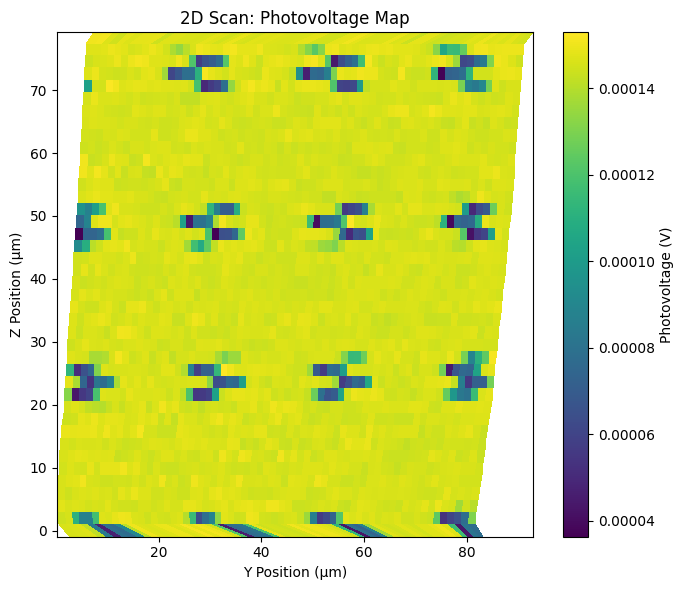

In [99]:

import matplotlib.pyplot as plt
import numpy as np

y, z, r = np.loadtxt("scanData/scan_yz_20260604_122343.csv", delimiter=",", skiprows=1, unpack=True)
y = y[::-1]

n_y, n_z = 64, 41

Y = y.reshape(n_z, n_y)
Z = z.reshape(n_z, n_y)
R = r.reshape(n_z, n_y)

print(R)

# Reverse every other row (snake pattern correction)
Y[1::2, :] = Y[1::2, ::-1]
Z[1::2, :] = Z[1::2, ::-1]
R[1::2, :] = R[1::2, ::-1]

print(R)

x_flat = Y.flatten()
y_flat = Z.flatten()

# Convert to microns
x_flat = (Y - Y.min()) * 1000
y_flat = (Z - Z.min()) * 1000

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(x_flat, y_flat, R, shading='auto', cmap='viridis')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Photovoltage (V)')
ax.set_xlabel('Y Position (µm)')
ax.set_ylabel('Z Position (µm)')
ax.set_title('2D Scan: Photovoltage Map')
plt.tight_layout()
plt.show()

In [ ]:
# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten()
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")


>> Saved 5000 points to /Users/lingwen/Desktop/PhD/QWM Github/QWM/RenSciPiezo/scanData/scan_yz_20260604_111127.csv


Grid: 2619 x 1668 = 4368492, points: 2624


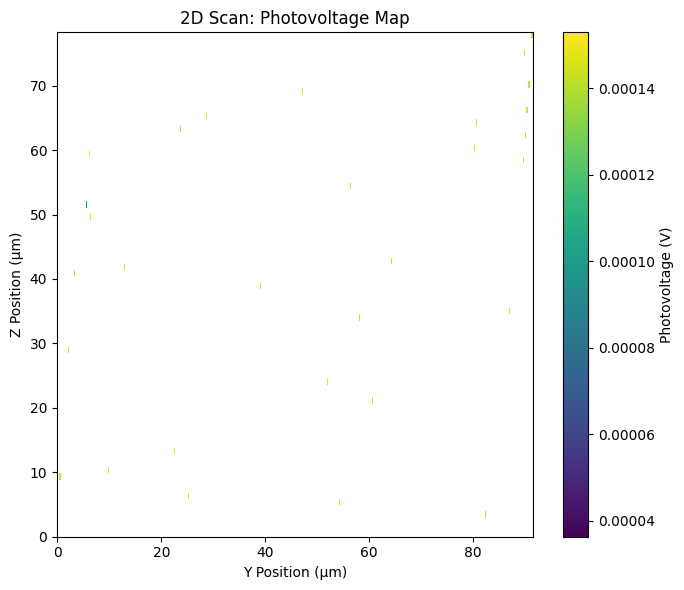

In [89]:
import matplotlib.pyplot as plt
import numpy as np

y, z, r = np.loadtxt("scanData/scan_yz_20260604_122343.csv", delimiter=",", skiprows=1, unpack=True)
y = y[::-1]

n_y, n_z = 64, 41

Y = y.reshape(n_z, n_y)
Z = z.reshape(n_z, n_y)
R = r.reshape(n_z, n_y)

# Reverse every other row (snake pattern correction)
Y[1::2, :] = Y[1::2, ::-1]
Z[1::2, :] = Z[1::2, ::-1]
R[1::2, :] = R[1::2, ::-1]

# Convert to microns and flatten
x_flat = ((Y - Y.min()) * 1000).flatten()
y_flat = ((Z - Z.min()) * 1000).flatten()
f_flat = R.flatten()

# Find unique coordinates
x_unique = np.unique(np.round(x_flat, 4))
y_unique = np.unique(np.round(y_flat, 4))
nx = len(x_unique)
ny = len(y_unique)
print(f"Grid: {nx} x {ny} = {nx*ny}, points: {len(f_flat)}")

# Build lookup and fill 2D array
x_idx = {v: i for i, v in enumerate(x_unique)}
y_idx = {v: i for i, v in enumerate(y_unique)}

F = np.full((ny, nx), np.nan)
for xi, yi, fi in zip(np.round(x_flat, 4), np.round(y_flat, 4), f_flat):
    F[y_idx[yi], x_idx[xi]] = fi

# Build meshgrid and plot
X2D, Y2D = np.meshgrid(x_unique, y_unique)

fig, ax = plt.subplots(figsize=(7, 6))
pcm = ax.pcolormesh(X2D, Y2D, F, shading='auto', cmap='viridis')
fig.colorbar(pcm, ax=ax, label='Photovoltage (V)')
ax.set_xlabel('Y Position (µm)')
ax.set_ylabel('Z Position (µm)')
ax.set_title('2D Scan: Photovoltage Map')
plt.tight_layout()
plt.show()

In [35]:
z.shape

(2624,)

In [36]:
r.shape

(2624,)

In [103]:
xyz.goPosition(2, -1.15)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -3.235)

True

In [104]:
# 06/04/2026 - Lingwen
# large 2D scan test

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
stepsize = 300         # scanning resolution; smaller = higher res, slower
scanYSize = 3     # total scan size in Y (mm)
scanZSize = 2     # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.5)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -3.235)
currentXPosition = xyz.getPosition(1)
currentYPosition = xyz.getPosition(2)
currentZPosition = xyz.getPosition(3)

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=stepsize, nsteps=10)
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * stepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * stepsize:.4f}")
n_y = int(round(scanYSize / (yOneStepDistance*stepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*stepsize)))
print(f"   Total steps: {n_y} in Y, {n_z} in Z")
#print(f"   scanYSize={scanYSize}, yOneStepDistance={yOneStepDistance:.6f}, stepsize={stepsize}")
#print(f"   scanZSize={scanZSize}, zOneStepDistance={zOneStepDistance:.6f}, stepsize={stepsize}")
#print(f"   n_y={n_y}, n_z={n_z}")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=5,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=20, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")

for i in range(n_z):
    xyz.goStepsForward(3, steps=stepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=stepsize)
        else:
            xyz.goStepsReverse(2, steps=stepsize)
        time.sleep(lockin.time_constant * 5)  # wait for lock-in to settle
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_z + j + 1) / total_steps * 100)
        milestone = (pct // 5) * 5
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {j+1}/{n_z}, y step {i+1}/{n_y})")
            last_reported = milestone

print(">> Scan complete.")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten()
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")


>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0003 mm/step
  Y Resolution (mm/step): 0.0779
  Z Resolution (mm/step): 0.0898
   Total steps: 39 in Y, 22 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.591 mm
>> Starting 2D scan (39 x 22 = 858 points)...
   Progress: 0%  (z step 1/22, y step 1/39)
   Progress: 5%  (z step 21/22, y step 2/39)
   Progress: 10%  (z step 20/22, y step 4/39)
   Progress: 15%  (z step 19/22, y step 6/39)
   Progress: 20%  (z step 18/22, y step 8/39)
   Progress: 25%  (z step 39/22, y step 9/39)
   Progress: 30%  (z step 38/22, y step 11/39)
   Progress: 35%  (z step 37/22, y step 13/39)
   Progress: 40%  (z step 36/22, y step 15/39)
   Progress: 45%  (z step 35/22, y step 17/39)
   Progress: 50%  (z step 33/22, y step 19/39)
   Progress: 55%  (z step 32/22, y step 21/39)
>> Scan complete.
>> Saved 858 points to /Users/lingwen/Desktop/PhD/QWM Git

In [105]:
# 06/04/2026 - Lingwen
# precise feasure 2D scan test

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
stepsize = 20         # scanning resolution; smaller = higher res, slower
scanYSize = 0.5     # total scan size in Y (mm)
scanZSize = 0.5    # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.5)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -3.235-0.8)
currentXPosition = xyz.getPosition(1)
currentYPosition = xyz.getPosition(2)
currentZPosition = xyz.getPosition(3)

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=stepsize, nsteps=10)
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * stepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * stepsize:.4f}")
n_y = int(round(scanYSize / (yOneStepDistance*stepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*stepsize)))
print(f"   Total steps: {n_y} in Y, {n_z} in Z")
#print(f"   scanYSize={scanYSize}, yOneStepDistance={yOneStepDistance:.6f}, stepsize={stepsize}")
#print(f"   scanZSize={scanZSize}, zOneStepDistance={zOneStepDistance:.6f}, stepsize={stepsize}")
#print(f"   n_y={n_y}, n_z={n_z}")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=5,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=20, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")

for i in range(n_z):
    xyz.goStepsForward(3, steps=stepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=stepsize)
        else:
            xyz.goStepsReverse(2, steps=stepsize)
        time.sleep(lockin.time_constant * 5)  # wait for lock-in to settle
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_z + j + 1) / total_steps * 100)
        milestone = (pct // 5) * 5
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {j+1}/{n_z}, y step {i+1}/{n_y})")
            last_reported = milestone

print(">> Scan complete.")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten()
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")


>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0003 mm/step
  Y Resolution (mm/step): 0.0053
  Z Resolution (mm/step): 0.0064
   Total steps: 95 in Y, 78 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.590 mm
>> Starting 2D scan (95 x 78 = 7410 points)...
   Progress: 0%  (z step 1/78, y step 1/95)
   Progress: 5%  (z step 59/78, y step 5/95)
   Progress: 10%  (z step 39/78, y step 10/95)
   Progress: 15%  (z step 20/78, y step 15/95)
   Progress: 20%  (z step 78/78, y step 19/95)
   Progress: 25%  (z step 59/78, y step 24/95)
   Progress: 30%  (z step 39/78, y step 29/95)
   Progress: 35%  (z step 20/78, y step 34/95)
   Progress: 40%  (z step 78/78, y step 38/95)
   Progress: 45%  (z step 59/78, y step 43/95)
   Progress: 50%  (z step 39/78, y step 48/95)
   Progress: 55%  (z step 20/78, y step 53/95)
   Progress: 60%  (z step 78/78, y step 57/95)
   Progress: 65%  (z st

In [ ]:
# 06/04/2026 - Lingwen
# precise feasure 2D scan test , scan 2

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
stepsize = 200         # scanning resolution; smaller = higher res, slower
scanYSize = 3    # total scan size in Y (mm)
scanZSize = 0.75    # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.5)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -4)
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=stepsize, nsteps=10)
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * stepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * stepsize:.4f}")
n_y = int(round(scanYSize / (yOneStepDistance*stepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*stepsize)))
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=5,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=20, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")

xyz.goPosition(2, startYPosition - scanYSize/2)
xyz.goPosition(3, startZPosition - scanZSize/2)

for i in range(n_z):
    xyz.goStepsForward(3, steps=stepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=stepsize)
        else:
            xyz.goStepsReverse(2, steps=stepsize)
        time.sleep(lockin.time_constant * 5)  # wait for lock-in to settle
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_z + j * n_y) / total_steps * 100)
        if pct > last_reported:
            print(f"   Progress: {pct}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = pct

print()
print(">> Scan complete.")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")


>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0003 mm/step
  Y Resolution (mm/step): 0.0538
  Z Resolution (mm/step): 0.0585
   Total steps: 56 in Y, 13 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.591 mm
>> Starting 2D scan (56 x 13 = 728 points)...
   Progress: 0%  (z step 1/13, y step 1/56)
   Progress: 1%  (z step 8/13, y step 1/56)
   Progress: 2%  (z step 15/13, y step 1/56)
   Progress: 3%  (z step 22/13, y step 1/56)
   Progress: 4%  (z step 30/13, y step 1/56)
   Progress: 5%  (z step 37/13, y step 1/56)
   Progress: 6%  (z step 44/13, y step 1/56)
   Progress: 7%  (z step 51/13, y step 1/56)
   Progress: 8%  (z step 46/13, y step 2/56)
   Progress: 9%  (z step 53/13, y step 2/56)
   Progress: 10%  (z step 47/13, y step 3/56)
   Progress: 11%  (z step 55/13, y step 3/56)
   Progress: 12%  (z step 49/13, y step 4/56)
   Progress: 13%  (z step 56/13, y step 4/56

In [ ]:
# 06/04/2026 - Lingwen
# precise feasure 2D scan test , scan 3

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
stepsize = 300         # scanning resolution; smaller = higher res, slower
scanYSize = 2.5   # total scan size in Y (mm)
scanZSize = 0.5    # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.5)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -4.75)
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=stepsize, nsteps=10)
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * stepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * stepsize:.4f}")
n_y = int(round(scanYSize / (yOneStepDistance*stepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*stepsize)))
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=5,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=20, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")

xyz.goPosition(2, startYPosition - scanYSize/2)
xyz.goPosition(3, startZPosition + scanZSize/2)

for i in range(n_z):
    xyz.goStepsForward(3, steps=stepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=stepsize)
        else:
            xyz.goStepsReverse(2, steps=stepsize)
        time.sleep(lockin.time_constant * 5)  # wait for lock-in to settle
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 5) * 5
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

print(">> Scan complete.")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")


>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0003 mm/step
  Y Resolution (mm/step): 0.0802
  Z Resolution (mm/step): 0.0894
   Total steps: 31 in Y, 6 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.593 mm
>> Starting 2D scan (31 x 6 = 186 points)...
>> Scan complete.  (z step 6/6, y step 31/31)
>> Saved 186 points to /Users/lingwen/Desktop/PhD/QWM Github/QWM/RenSciPiezo/scanData/scan_yz_20260604_192859.csv


In [ ]:
# 06/04/2026 - Lingwen
# precise feasure 2D scan test , scan 4

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
stepsize = 200         # scanning resolution; smaller = higher res, slower
scanYSize = 3   # total scan size in Y (mm)
scanZSize = 0.5    # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.5)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -4.75)
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=stepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=stepsize, nsteps=10)
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * stepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * stepsize:.4f}")
n_y = int(round(scanYSize / (yOneStepDistance*stepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*stepsize)))
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=5,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=15, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")

xyz.goPosition(2, startYPosition - scanYSize/2)
xyz.goPosition(3, startZPosition - scanZSize/2)

for i in range(n_z):
    xyz.goStepsReverse(3, steps=stepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=stepsize)
        else:
            xyz.goStepsReverse(2, steps=stepsize)
        time.sleep(lockin.time_constant * 5)  # wait for lock-in to settle
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 5) * 5
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

print(">> Scan complete.")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")


>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0001 mm/step
  Y Resolution (mm/step): 0.0540
  Z Resolution (mm/step): 0.0223
   Total steps: 56 in Y, 22 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.591 mm
>> Starting 2D scan (56 x 22 = 1232 points)...
>> Scan complete.  (z step 22/22, y step 56/56)
>> Saved 1232 points to /Users/lingwen/Desktop/PhD/QWM Github/QWM/RenSciPiezo/scanData/scan_yz_20260604_194945.csv


In [128]:
# 06/05/2026 - Lingwen
# precise feasure 2D scan test , scan 5

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
ystepsize = 70        # scanning resolution; smaller = higher res, slower, usually 0.3 micron/step
zstepsize = 70         # scanning resolution; smaller = higher res, slower, usually 0.1 micron/step
scanYSize = 0.4   # total scan size in Y (mm)
scanZSize = 0.4    # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -2)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -4.82)
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=ystepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
zstepsize = yOneStepDistance/zOneStepDistance*ystepsize  # adjust z stepsize to match y stepsize in physical distance
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
n_y = int(round(scanYSize / (yOneStepDistance*ystepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*zstepsize)))
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * ystepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * zstepsize:.4f}")
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=5,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=15, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

# ── Scan time estimate ────────────────────────────────────
from datetime import datetime, timedelta
scan_start_time = datetime.now()
estimated_minutes = total_steps / 1000 * 16
estimated_end_time = scan_start_time + timedelta(minutes=estimated_minutes)
print(f"\n========== SCAN TIME ESTIMATE ==========")
print(f"  Total points       : {total_steps}")
print(f"  Estimated duration : {estimated_minutes:.1f} min  ({estimated_minutes/60:.2f} hrs)")
print(f"  Start time         : {scan_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Estimated end time : {estimated_end_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"========================================\n")

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")

xyz.goPosition(2, startYPosition - scanYSize/2)     
xyz.goPosition(3, startZPosition - scanZSize/2)

for i in range(n_z):
    xyz.goStepsReverse(3, steps=zstepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=ystepsize)
        else:
            xyz.goStepsReverse(2, steps=ystepsize)
        time.sleep(lockin.time_constant * 5)  # wait for lock-in to settle
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 1) * 1
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

print("\n>> Scan complete.")
scan_end_time = datetime.now()
elapsed = scan_end_time - scan_start_time
print(f"   Start time   : {scan_start_time.strftime('%H:%M:%S')}")
print(f"   End time     : {scan_end_time.strftime('%H:%M:%S')}")
print(f"   Elapsed time : {str(elapsed).split('.')[0]}")  # trim microseconds

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")


>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0001 mm/step
  Y Resolution (mm/step): 0.0184
  Z Resolution (mm/step): 0.0188
   Total steps: 22 in Y, 21 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.604 mm

========== SCAN TIME ESTIMATE ==========
  Total points       : 462
  Estimated duration : 7.4 min  (0.12 hrs)
  Start time         : 2026-06-05 09:34:58
  Estimated end time : 2026-06-05 09:42:22

>> Starting 2D scan (22 x 21 = 462 points)...
   Progress: 100%  (z step 21/21, y step 22/22)
>> Scan complete.
   Start time   : 09:34:58
   End time     : 09:40:49
   Elapsed time : 0:05:51
>> Saved 462 points to /Users/lingwen/Desktop/PhD/QWM Github/QWM/RenSciPiezo/scanData/scan_yz_20260605_094049.csv


In [133]:
# 06/05/2026 - Lingwen
# precise feasure 2D scan test , scan 6

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
targetResolution = 40
ystepsize = targetResolution/0.3        # scanning resolution; smaller = higher res, slower, usually 0.3 micron/step
zstepsize = targetResolution/0.1         # scanning resolution; smaller = higher res, slower, usually 0.1 micron/step
scanYSize = 3   # total scan size in Y (mm)
scanZSize = 0.3   # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.25)
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -4.82)
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=ystepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
zstepsize = yOneStepDistance/zOneStepDistance*ystepsize  # adjust z stepsize to match y stepsize in physical distance
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
n_y = int(round(scanYSize / (yOneStepDistance*ystepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*zstepsize)))
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * ystepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * zstepsize:.4f}")
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=5,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=15, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

# ── Scan time estimate ────────────────────────────────────
from datetime import datetime, timedelta
scan_start_time = datetime.now()
estimated_minutes = total_steps / 1000 * 16
estimated_end_time = scan_start_time + timedelta(minutes=estimated_minutes)
print(f"\n========== SCAN TIME ESTIMATE ==========")
print(f"  Total points       : {total_steps}")
print(f"  Estimated duration : {estimated_minutes:.1f} min  ({estimated_minutes/60:.2f} hrs)")
print(f"  Start time         : {scan_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Estimated end time : {estimated_end_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"========================================\n")

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")

xyz.goPosition(2, startYPosition - scanYSize/2)     
xyz.goPosition(3, startZPosition - scanZSize/2)

for i in range(n_z):
    xyz.goStepsReverse(3, steps=zstepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=ystepsize)
        else:
            xyz.goStepsReverse(2, steps=ystepsize)
        time.sleep(lockin.time_constant * 5)  # wait for lock-in to settle
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 1) * 1
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

print("\n>> Scan complete.")
scan_end_time = datetime.now()
elapsed = scan_end_time - scan_start_time
print(f"   Start time   : {scan_start_time.strftime('%H:%M:%S')}")
print(f"   End time     : {scan_end_time.strftime('%H:%M:%S')}")
print(f"   Elapsed time : {str(elapsed).split('.')[0]}")  # trim microseconds

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")


>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0001 mm/step
  Y Resolution (mm/step): 0.0360
  Z Resolution (mm/step): 0.0383
   Total steps: 83 in Y, 8 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.605 mm

========== SCAN TIME ESTIMATE ==========
  Total points       : 664
  Estimated duration : 10.6 min  (0.18 hrs)
  Start time         : 2026-06-05 10:21:40
  Estimated end time : 2026-06-05 10:32:18

>> Starting 2D scan (83 x 8 = 664 points)...
   Progress: 100%  (z step 8/8, y step 83/83)
>> Scan complete.
   Start time   : 10:21:40
   End time     : 10:30:49
   Elapsed time : 0:09:08
>> Saved 664 points to /Users/lingwen/Desktop/PhD/QWM Github/QWM/RenSciPiezo/scanData/scan_yz_20260605_103049.csv


In [136]:
# 06/05/2026 - Lingwen
# precise feasure 2D scan test , scan 7

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
targetResolution = 20
ystepsize = targetResolution/0.3        # scanning resolution; smaller = higher res, slower, usually 0.3 micron/step
zstepsize = targetResolution/0.1         # scanning resolution; smaller = higher res, slower, usually 0.1 micron/step
scanYSize = 2   # total scan size in Y (mm)
scanZSize = 2   # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.25) #set y position at the center of the scan
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -4.815) #set z position at the center of the scan
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=ystepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
zstepsize = yOneStepDistance/zOneStepDistance*ystepsize  # adjust z stepsize to match y stepsize in physical distance
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
n_y = int(round(scanYSize / (yOneStepDistance*ystepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*zstepsize)))
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * ystepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * zstepsize:.4f}")
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=5,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=15, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

# ── Scan time estimate ────────────────────────────────────
from datetime import datetime, timedelta
scan_start_time = datetime.now()
estimated_minutes = total_steps / 1000 * 15
estimated_end_time = scan_start_time + timedelta(minutes=estimated_minutes)
print(f"\n========== SCAN TIME ESTIMATE ==========")
print(f"  Total points       : {total_steps}")
print(f"  Estimated duration : {estimated_minutes:.1f} min  ({estimated_minutes/60:.2f} hrs)")
print(f"  Start time         : {scan_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Estimated end time : {estimated_end_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"========================================\n")

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")

xyz.goPosition(2, startYPosition - scanYSize/2)     
xyz.goPosition(3, startZPosition - scanZSize/2)

for i in range(n_z):
    xyz.goStepsReverse(3, steps=zstepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=ystepsize)
        else:
            xyz.goStepsReverse(2, steps=ystepsize)
        time.sleep(lockin.time_constant * 5)  # wait for lock-in to settle
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 1) * 1
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

print("\n>> Scan complete.")
scan_end_time = datetime.now()
elapsed = scan_end_time - scan_start_time
print(f"   Start time   : {scan_start_time.strftime('%H:%M:%S')}")
print(f"   End time     : {scan_end_time.strftime('%H:%M:%S')}")
print(f"   Elapsed time : {str(elapsed).split('.')[0]}")  # trim microseconds

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")


>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0001 mm/step
  Y Resolution (mm/step): 0.0181
  Z Resolution (mm/step): 0.0191
   Total steps: 110 in Y, 105 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.605 mm

========== SCAN TIME ESTIMATE ==========
  Total points       : 11550
  Estimated duration : 184.8 min  (3.08 hrs)
  Start time         : 2026-06-05 10:51:09
  Estimated end time : 2026-06-05 13:55:57

>> Starting 2D scan (110 x 105 = 11550 points)...
   Progress: 100%  (z step 105/105, y step 110/110)
>> Scan complete.
   Start time   : 10:51:09
   End time     : 13:13:00
   Elapsed time : 2:21:50
>> Saved 11550 points to /Users/lingwen/Desktop/PhD/QWM Github/QWM/RenSciPiezo/scanData/scan_yz_20260605_131300.csv


In [139]:
# 06/05/2026 - Lingwen
# precise feasure 2D scan test , scan 8

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
targetResolution = 150
ystepsize = targetResolution/0.3        # scanning resolution; smaller = higher res, slower, usually 0.3 micron/step
zstepsize = targetResolution/0.1         # scanning resolution; smaller = higher res, slower, usually 0.1 micron/step
scanYSize = 4   # total scan size in Y (mm)
scanZSize = 2   # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.15) #set y position at the center of the scan
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -2.475) #set z position at the center of the scan
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)
print("YLocation: {startYPosition:.4f}")

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=ystepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
zstepsize = yOneStepDistance/zOneStepDistance*ystepsize  # adjust z stepsize to match y stepsize in physical distance
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
n_y = int(round(scanYSize / (yOneStepDistance*ystepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*zstepsize)))
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * ystepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * zstepsize:.4f}")
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=5,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=15, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

# ── Scan time estimate ────────────────────────────────────
from datetime import datetime, timedelta
scan_start_time = datetime.now()
estimated_minutes = total_steps / 1500 * 15
estimated_end_time = scan_start_time + timedelta(minutes=estimated_minutes)
print(f"\n========== SCAN TIME ESTIMATE ==========")
print(f"  Total points       : {total_steps}")
print(f"  Estimated duration : {estimated_minutes:.1f} min  ({estimated_minutes/60:.2f} hrs)")
print(f"  Start time         : {scan_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Estimated end time : {estimated_end_time.strftime('%Y-%m-%d %H:%M:%S')}  (rough)")
print(f"========================================\n")

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")


print("YLocation: {startYPosition:.4f - scanYSize/2:.4}")
xyz.goPosition(2, startYPosition - scanYSize/2)
xyz.goPosition(3, startZPosition - scanZSize/2)

updated_3pct  = False
updated_10pct = False

for i in range(n_z):
    xyz.goStepsReverse(3, steps=zstepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=ystepsize)
        else:
            xyz.goStepsReverse(2, steps=ystepsize)
        time.sleep(lockin.time_constant * 5)
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 5) * 5
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

        # Refined estimate after 3%
        if not updated_3pct and pct >= 3:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100  # (current% - 0%) / elapsed = rate
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [3% update]  Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")
            updated_3pct = True

        # Refined estimate after 10%
        if not updated_10pct and pct >= 10:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [10% update] Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")
            updated_10pct = True

print("\n>> Scan complete.")
scan_end_time = datetime.now()
elapsed = scan_end_time - scan_start_time
print(f"   Start time   : {scan_start_time.strftime('%H:%M:%S')}")
print(f"   End time     : {scan_end_time.strftime('%H:%M:%S')}")
print(f"   Elapsed time : {str(elapsed).split('.')[0]}")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")

-1.149987554521283

>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0001 mm/step
  Y Resolution (mm/step): 0.1348
  Z Resolution (mm/step): 0.1520
   Total steps: 30 in Y, 13 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.603 mm

========== SCAN TIME ESTIMATE ==========
  Total points       : 390
  Estimated duration : 3.9 min  (0.07 hrs)
  Start time         : 2026-06-05 13:28:11
  Estimated end time : 2026-06-05 13:32:05  (rough)

>> Starting 2D scan (30 x 13 = 390 points)...
-3.149987554521283
   Progress: 0%  (z step 1/13, y step 1/30)
   [3% update]  Refined duration : 21.4 min
               Refined end time : 13:49:36
   Progress: 10%  (z step 2/13, y step 9/30)
   [10% update] Refined duration : 11.9 min
               Refined end time : 13:40:05
   Progress: 100%  (z step 13/13, y step 30/30)
>> Scan complete.
   Start time   : 13:28:11
   End time     : 13:36:27
 

In [ ]:
# 06/05/2026 - Lingwen
# precise feasure 2D scan test , scan 9

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
targetResolution = 30
ystepsize = targetResolution/0.3        # scanning resolution; smaller = higher res, slower, usually 0.3 micron/step
zstepsize = targetResolution/0.1         # scanning resolution; smaller = higher res, slower, usually 0.1 micron/step
scanYSize = 0.5   # total scan size in Y (mm)
scanZSize = 0.3   # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.15) #set y position at the center of the scan
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -2.475) #set z position at the center of the scan
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)
print(f"YLocation: {startYPosition}")

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=ystepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
zstepsize = yOneStepDistance/zOneStepDistance*ystepsize  # adjust z stepsize to match y stepsize in physical distance
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
n_y = int(round(scanYSize / (yOneStepDistance*ystepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*zstepsize)))
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * ystepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * zstepsize:.4f}")
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=10,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=15, stepsize=5,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=15, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

# ── Scan time estimate ────────────────────────────────────
from datetime import datetime, timedelta
scan_start_time = datetime.now()
estimated_minutes = total_steps / 1500 * 15
estimated_end_time = scan_start_time + timedelta(minutes=estimated_minutes)
print(f"\n========== SCAN TIME ESTIMATE ==========")
print(f"  Total points       : {total_steps}")
print(f"  Estimated duration : {estimated_minutes:.1f} min  ({estimated_minutes/60:.2f} hrs)")
print(f"  Start time         : {scan_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Estimated end time : {estimated_end_time.strftime('%Y-%m-%d %H:%M:%S')}  (rough)")
print(f"========================================\n")

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")


print(f"YLocation: {startYPosition:.4f - scanYSize/2:.4}")
xyz.goPosition(2, startYPosition - scanYSize/2)
xyz.goPosition(3, startZPosition - scanZSize/2)

updated_3pct  = False
updated_10pct = False

for i in range(n_z):
    xyz.goStepsReverse(3, steps=zstepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=ystepsize)
        else:
            xyz.goStepsReverse(2, steps=ystepsize)
        time.sleep(lockin.time_constant * 5)
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 5) * 5
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

        # Refined estimate after 3%
        if not updated_3pct and pct >= 3:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100  # (current% - 0%) / elapsed = rate
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [3% update]  Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")
            updated_3pct = True

        # Refined estimate after 10%
        if not updated_10pct and pct >= 10:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [10% update] Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")
            updated_10pct = True

print("\n>> Scan complete.")
scan_end_time = datetime.now()
elapsed = scan_end_time - scan_start_time
print(f"   Start time   : {scan_start_time.strftime('%H:%M:%S')}")
print(f"   End time     : {scan_end_time.strftime('%H:%M:%S')}")
print(f"   Elapsed time : {str(elapsed).split('.')[0]}")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")

YLocation: {startYPosition}

>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0001 mm/step
  Y Resolution (mm/step): 0.0271
  Z Resolution (mm/step): 0.0282
   Total steps: 18 in Y, 11 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.602 mm

========== SCAN TIME ESTIMATE ==========
  Total points       : 198
  Estimated duration : 2.0 min  (0.03 hrs)
  Start time         : 2026-06-05 13:42:50
  Estimated end time : 2026-06-05 13:44:49  (rough)

>> Starting 2D scan (18 x 11 = 198 points)...
YLocation: {startYPosition:.4f - scanYSize/2:.4}
   Progress: 0%  (z step 1/11, y step 1/18)
   [3% update]  Refined duration : 7.2 min
               Refined end time : 13:50:02
   Progress: 10%  (z step 2/11, y step 2/18)
   [10% update] Refined duration : 4.0 min
               Refined end time : 13:46:48
   Progress: 100%  (z step 11/11, y step 18/18)
>> Scan complete.
   Start time   : 

In [147]:
# 06/05/2026 - Lingwen
# precise feasure 2D scan test , scan 10

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
targetResolution = 4
ystepsize = targetResolution/0.3        # scanning resolution; smaller = higher res, slower, usually 0.3 micron/step
zstepsize = targetResolution/0.1         # scanning resolution; smaller = higher res, slower, usually 0.1 micron/step
scanYSize = 0.2   # total scan size in Y (mm)
scanZSize = 0.2   # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.1) #set y position at the center of the scan
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -2.45) #set z position at the center of the scan
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)
print(f"YLocation: {startYPosition}")

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=ystepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
zstepsize = yOneStepDistance/zOneStepDistance*ystepsize  # adjust z stepsize to match y stepsize in physical distance
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
n_y = int(round(scanYSize / (yOneStepDistance*ystepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*zstepsize)))
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * ystepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * zstepsize:.4f}")
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=10, stepsize=8,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=10, stepsize=3,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=10, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

# ── Scan time estimate ────────────────────────────────────
from datetime import datetime, timedelta
scan_start_time = datetime.now()
estimated_minutes = total_steps / 1500 * 15
estimated_end_time = scan_start_time + timedelta(minutes=estimated_minutes)
print(f"\n========== SCAN TIME ESTIMATE ==========")
print(f"  Total points       : {total_steps}")
print(f"  Estimated duration : {estimated_minutes:.1f} min  ({estimated_minutes/60:.2f} hrs)")
print(f"  Start time         : {scan_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Estimated end time : {estimated_end_time.strftime('%Y-%m-%d %H:%M:%S')}  (rough)")
print(f"========================================\n")

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")
xyz.goPosition(2, startYPosition - scanYSize/2)
xyz.goPosition(3, startZPosition - scanZSize/2)

updated_3pct  = False
updated_10pct = False

for i in range(n_z):
    xyz.goStepsReverse(3, steps=zstepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=ystepsize)
        else:
            xyz.goStepsReverse(2, steps=ystepsize)
        time.sleep(lockin.time_constant * 5)
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 5) * 5
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

        # Refined estimate after 3%
        if not updated_3pct and pct >= 3:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100  # (current% - 0%) / elapsed = rate
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [3% update]  Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")

            updated_3pct = True

        # Refined estimate after 10%
        if not updated_10pct and pct >= 10:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [10% update] Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")
            
            updated_10pct = True

print("\n>> Scan complete.")
scan_end_time = datetime.now()
elapsed = scan_end_time - scan_start_time
print(f"   Start time   : {scan_start_time.strftime('%H:%M:%S')}")
print(f"   End time     : {scan_end_time.strftime('%H:%M:%S')}")
print(f"   Elapsed time : {str(elapsed).split('.')[0]}")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")

YLocation: -1.1000093960645865

>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0001 mm/step
  Y Resolution (mm/step): 0.0035
  Z Resolution (mm/step): 0.0037
   Total steps: 57 in Y, 55 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.601 mm

========== SCAN TIME ESTIMATE ==========
  Total points       : 3135
  Estimated duration : 31.3 min  (0.52 hrs)
  Start time         : 2026-06-05 14:00:15
  Estimated end time : 2026-06-05 14:31:36  (rough)

>> Starting 2D scan (57 x 55 = 3135 points)...
   Progress: 0%  (z step 1/55, y step 1/57)
   [3% update]  Refined duration : 39.4 min
               Refined end time : 14:39:37
   Progress: 10%  (z step 6/55, y step 29/57)
   [10% update] Refined duration : 36.4 min
               Refined end time : 14:36:40
   Progress: 100%  (z step 55/55, y step 57/57)
>> Scan complete.
   Start time   : 14:00:15
   End time     : 14:35:43
   E

In [152]:
# 06/05/2026 - Lingwen
# zigzag
# precise feasure 2D scan test , scan 11

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 1e-3
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
targetResolution = 1
ystepsize = targetResolution/0.3        # scanning resolution; smaller = higher res, slower, usually 0.3 micron/step
zstepsize = targetResolution/0.1         # scanning resolution; smaller = higher res, slower, usually 0.1 micron/step
scanYSize = 0.15   # total scan size in Y (mm)
scanZSize = 0.065   # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.075) #set y position at the center of the scan
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -2.47) #set z position at the center of the scan
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)
print(f"YLocation: {startYPosition}")

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=ystepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
zstepsize = yOneStepDistance/zOneStepDistance*ystepsize  # adjust z stepsize to match y stepsize in physical distance
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
n_y = int(round(scanYSize / (yOneStepDistance*ystepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*zstepsize)))
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * ystepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * zstepsize:.4f}")
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=10, stepsize=8,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=10, stepsize=3,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=10, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

# ── Scan time estimate ────────────────────────────────────
from datetime import datetime, timedelta
scan_start_time = datetime.now()
estimated_minutes = total_steps / 1500 * 15
estimated_end_time = scan_start_time + timedelta(minutes=estimated_minutes)
print(f"\n========== SCAN TIME ESTIMATE ==========")
print(f"  Total points       : {total_steps}")
print(f"  Estimated duration : {estimated_minutes:.1f} min  ({estimated_minutes/60:.2f} hrs)")
print(f"  Start time         : {scan_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Estimated end time : {estimated_end_time.strftime('%Y-%m-%d %H:%M:%S')}  (rough)")
print(f"========================================\n")

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")
xyz.goPosition(2, startYPosition - scanYSize/2)
xyz.goPosition(3, startZPosition - scanZSize/2)

updated_3pct  = False
updated_10pct = False

for i in range(n_z):
    xyz.goStepsReverse(3, steps=zstepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=ystepsize)
        else:
            xyz.goStepsReverse(2, steps=ystepsize)
        time.sleep(lockin.time_constant * 5)
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 1) * 1
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

        # Refined estimate after 3%
        if not updated_3pct and pct >= 3:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100  # (current% - 0%) / elapsed = rate
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [3% update]  Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")

            updated_3pct = True

        # Refined estimate after 10%
        if not updated_10pct and pct >= 10:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [10% update] Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")
            
            updated_10pct = True

print("\n>> Scan complete.")
scan_end_time = datetime.now()
elapsed = scan_end_time - scan_start_time
print(f"   Start time   : {scan_start_time.strftime('%H:%M:%S')}")
print(f"   End time     : {scan_end_time.strftime('%H:%M:%S')}")
print(f"   Elapsed time : {str(elapsed).split('.')[0]}")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")

KeyError: '150000'

In [145]:
xyz.goPosition(2, -1.1) #set y position at the center of the scan
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -2.45) #set z position at the center of the scan

True

In [ ]:
# 06/05/2026 - Lingwen
# linear scan
# precise feasure 2D scan test , scan 12

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 3e-5
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
targetResolution = 0.5
ystepsize = targetResolution/0.3        # scanning resolution; smaller = higher res, slower, usually 0.3 micron/step
zstepsize = targetResolution/0.1         # scanning resolution; smaller = higher res, slower, usually 0.1 micron/step
scanYSize = 0.05   # total scan size in Y (mm)
scanZSize = 0.03   # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.063) #set y position at the center of the scan
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -2.48) #set z position at the center of the scan
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)
print(f"YLocation: {startYPosition}")

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=ystepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
zstepsize = yOneStepDistance/zOneStepDistance*ystepsize  # adjust z stepsize to match y stepsize in physical distance
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
n_y = int(round(scanYSize / (yOneStepDistance*ystepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*zstepsize)))
print(f"   Y step distance: {yOneStepDistance:.4f} mm/step")
print(f"   Z step distance: {zOneStepDistance:.4f} mm/step")
print(f"  Y Resolution (mm/step): {yOneStepDistance * ystepsize:.4f}")
print(f"  Z Resolution (mm/step): {zOneStepDistance * zstepsize:.4f}")
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=10, stepsize=8,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=10, stepsize=3,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=10, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

# ── Scan time estimate ────────────────────────────────────
from datetime import datetime, timedelta
scan_start_time = datetime.now()

# Time per point: lock-in settle + measurement
time_per_point = lockin.time_constant * 3  # seconds
# Extra time per Z row: goPosition for Z + goPosition for Y return
time_per_zrow = 0.5  # seconds, adjust based on how fast goPosition is
estimated_seconds = total_steps * time_per_point + n_z * time_per_zrow
estimated_minutes = estimated_seconds / 60

estimated_end_time = scan_start_time + timedelta(seconds=estimated_seconds)
print(f"\n========== SCAN TIME ESTIMATE ==========")
print(f"  Total points       : {total_steps}")
print(f"  Time per point     : {time_per_point*1e3:.1f} ms")
print(f"  Estimated duration : {estimated_minutes:.1f} min  ({estimated_minutes/60:.2f} hrs)")
print(f"  Start time         : {scan_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Estimated end time : {estimated_end_time.strftime('%Y-%m-%d %H:%M:%S')}  (rough)")
print(f"========================================\n")

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")
xyz.goPosition(2, startYPosition - scanYSize/2)
xyz.goPosition(3, startZPosition - scanZSize/2)

updated_3pct  = False
updated_10pct = False
nextZPosition = startZPosition - scanZSize/2  # start from scan edge

for i in range(n_z):
    xyz.goStepsReverse(3, steps=zstepsize)
    xyz.goPosition(2, startYPosition - scanYSize/2)
    for j in range(n_y):
        xyz.goStepsForward(2, steps=ystepsize)
        time.sleep(lockin.time_constant * 3)
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 1) * 1
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

        # Refined estimate after 3%
        if not updated_3pct and pct >= 3:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100  # (current% - 0%) / elapsed = rate
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [3% update]  Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")

            updated_3pct = True

        # Refined estimate after 10%
        if not updated_10pct and pct >= 10:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [10% update] Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")
            
            updated_10pct = True

print("\n>> Scan complete.")
scan_end_time = datetime.now()
elapsed = scan_end_time - scan_start_time
print(f"   Start time   : {scan_start_time.strftime('%H:%M:%S')}")
print(f"   End time     : {scan_end_time.strftime('%H:%M:%S')}")
print(f"   Elapsed time : {str(elapsed).split('.')[0]}")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")

YLocation: -1.0629907355545996

>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0001 mm/step
  Y Resolution (mm/step): 0.0006
  Z Resolution (mm/step): 0.0006
   Total steps: 87 in Y, 52 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.592 mm

========== SCAN TIME ESTIMATE ==========
  Total points       : 4524
  Time per point     : 0.1 ms
  Estimated duration : 0.4 min  (0.01 hrs)
  Start time         : 2026-06-05 19:12:35
  Estimated end time : 2026-06-05 19:13:01  (rough)

>> Starting 2D scan (87 x 52 = 4524 points)...
   Progress: 3%  (z step 2/52, y step 49/87)
   [3% update]  Refined duration : 64.7 min
               Refined end time : 20:17:16
   Progress: 10%  (z step 6/52, y step 18/87)
   [10% update] Refined duration : 65.5 min
               Refined end time : 20:18:05
   Progress: 100%  (z step 52/52, y step 87/87)
>> Scan complete.
   Start time   : 19:12:35
 

In [ ]:
# 06/05/2026 - Lingwen
# zigzag scan
# precise feasure 2D scan test , scan 13

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 3e-5
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
targetResolution = 0.5
ystepsize = targetResolution/0.3        # scanning resolution; smaller = higher res, slower, usually 0.3 micron/step
zstepsize = targetResolution/0.1         # scanning resolution; smaller = higher res, slower, usually 0.1 micron/step
scanYSize = 0.032   # total scan size in Y (mm)
scanZSize = 0.018   # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.083) #set y position at the center of the scan
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -2.475) #set z position at the center of the scan
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)
print(f"YLocation: {startYPosition}")

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=ystepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
zstepsize = yOneStepDistance/zOneStepDistance*ystepsize  # adjust z stepsize to match y stepsize in physical distance
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
n_y = int(round(scanYSize / (yOneStepDistance*ystepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*zstepsize)))
yOneStepDistanceUm = yOneStepDistance * 1e-3
zOneStepDistanceUm = zOneStepDistance * 1e-3
print(f"   Y step distance: {yOneStepDistanceUm:.3f} µm/step")
print(f"   Z step distance: {zOneStepDistanceUm:.3f} µm/step")
print(f"  Y Resolution (µm/step): {yOneStepDistance * ystepsize:.3f}")
print(f"  Z Resolution (µm/step): {zOneStepDistance * zstepsize:.3f}")
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=10, stepsize=8,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=10, stepsize=3,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=10, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

# ── Scan time estimate ────────────────────────────────────
from datetime import datetime, timedelta
scan_start_time = datetime.now()
estimated_minutes = total_steps / 1500 * 15
estimated_end_time = scan_start_time + timedelta(minutes=estimated_minutes)
print(f"\n========== SCAN TIME ESTIMATE ==========")
print(f"  Total points       : {total_steps}")
print(f"  Estimated duration : {estimated_minutes:.1f} min  ({estimated_minutes/60:.2f} hrs)")
print(f"  Start time         : {scan_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Estimated end time : {estimated_end_time.strftime('%Y-%m-%d %H:%M:%S')}  (rough)")
print(f"========================================\n")

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")
xyz.goPosition(2, startYPosition - scanYSize/2)
xyz.goPosition(3, startZPosition - scanZSize/2)

updated_3pct  = False
updated_10pct = False

for i in range(n_z):
    xyz.goStepsReverse(3, steps=zstepsize)
    for j in range(n_y):
        if i % 2 == 0:
            xyz.goStepsForward(2, steps=ystepsize)
        else:
            xyz.goStepsReverse(2, steps=ystepsize)
        time.sleep(lockin.time_constant * 5)
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 1) * 1
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

        # Refined estimate after 3%
        if not updated_3pct and pct >= 3:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100  # (current% - 0%) / elapsed = rate
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [3% update]  Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")

            updated_3pct = True

        # Refined estimate after 10%
        if not updated_10pct and pct >= 10:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [10% update] Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")
            
            updated_10pct = True

print("\n>> Scan complete.")
scan_end_time = datetime.now()
elapsed = scan_end_time - scan_start_time
print(f"   Start time   : {scan_start_time.strftime('%H:%M:%S')}")
print(f"   End time     : {scan_end_time.strftime('%H:%M:%S')}")
print(f"   Elapsed time : {str(elapsed).split('.')[0]}")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")

YLocation: -1.0829999543344702

>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0001 mm/step
  Y Resolution (mm/step): 0.0006
  Z Resolution (mm/step): 0.0006
   Total steps: 56 in Y, 30 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.590 mm

========== SCAN TIME ESTIMATE ==========
  Total points       : 1680
  Estimated duration : 16.8 min  (0.28 hrs)
  Start time         : 2026-06-05 20:55:15
  Estimated end time : 2026-06-05 21:12:03  (rough)

>> Starting 2D scan (56 x 30 = 1680 points)...
   Progress: 3%  (z step 1/30, y step 51/56)
   [3% update]  Refined duration : 26.0 min
               Refined end time : 21:21:13
   Progress: 10%  (z step 3/30, y step 56/56)
   [10% update] Refined duration : 24.9 min
               Refined end time : 21:20:10
   Progress: 100%  (z step 30/30, y step 56/56)
>> Scan complete.
   Start time   : 20:55:15
   End time     : 21:18:37
   

In [164]:
# 06/05/2026 - Lingwen
# linear scan
# precise feasure 2D scan test , scan 14

#lock-in setting
lockin.amplitude = 0.15
lockin.frequency = 150*1e3
lockin.time_constant = 3e-5
lockin.sensitivity = 500*1e-6
lockin.phase = 0
lockin.filter_slope = 18

# Parameters (defined first)
targetResolution = 0.3
ystepsize = targetResolution/0.3        # scanning resolution; smaller = higher res, slower, usually 0.3 micron/step
zstepsize = targetResolution/0.1         # scanning resolution; smaller = higher res, slower, usually 0.1 micron/step
scanYSize = 0.015   # total scan size in Y (mm)
scanZSize = 0.0085  # total scan size in Z (mm)

# Initialize position
xyz.goPosition(2, -1.072) #set y position at the center of the scan
xyz.goPosition(1, 4.592440)
xyz.goPosition(3, -2.476) #set z position at the center of the scan
startXPosition = xyz.getPosition(1)
startYPosition = xyz.getPosition(2)
startZPosition = xyz.getPosition(3)
print(f"YLocation: {startYPosition}")

# Calibrate step distance and compute number of steps
print("\n>> Calibrating step distance...")
yOneStepDistance = getStepDistance(channel=2, stepSize=ystepsize, nsteps=10)
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
zstepsize = yOneStepDistance/zOneStepDistance*ystepsize  # adjust z stepsize to match y stepsize in physical distance
zOneStepDistance = getStepDistance(channel=3, stepSize=zstepsize, nsteps=10)
n_y = int(round(scanYSize / (yOneStepDistance*ystepsize)))
n_z = int(round(scanZSize / (zOneStepDistance*zstepsize)))
yOneStepDistanceUm = yOneStepDistance * 1e-3
zOneStepDistanceUm = zOneStepDistance * 1e-3
print(f"   Y step distance: {yOneStepDistanceUm:.3f} µm/step")
print(f"   Z step distance: {zOneStepDistanceUm:.3f} µm/step")
print(f"  Y Resolution (µm/step): {yOneStepDistance * ystepsize:.3f}")
print(f"  Z Resolution (µm/step): {zOneStepDistance * zstepsize:.3f}")
print(f"   Total steps: {n_y} in Y, {n_z} in Z")

# Refocus at the center of the scan area
print("\n>> Refocusing at scan center...")
print("   Coarse refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=10, stepsize=8,lockin_time_constant=lockin.time_constant)[0])
print("   Fine refocus...")
xyz.goPosition(1, refocus(channel=1, nsteps=10, stepsize=3,lockin_time_constant=lockin.time_constant)[0])
print("   Final refocus...")
x0 = refocus(channel=1, nsteps=10, stepsize=1,lockin_time_constant=lockin.time_constant)[0]
xyz.goPosition(1, x0)
print(f">> Refocused at x = {x0:.3f} mm")

# xyz.goStepsReverse(2, steps=stepsize*int(n_y/2))
# xyz.goStepsReverse(3, steps=stepsize*int(n_z/2))

r = np.zeros((n_z, n_y))
y = np.zeros((n_z, n_y))
z = np.zeros((n_z, n_y))

total_steps = n_y * n_z
last_reported = -1

# ── Scan time estimate ────────────────────────────────────
from datetime import datetime, timedelta
scan_start_time = datetime.now()

# Time per point: lock-in settle + measurement
time_per_point = lockin.time_constant * 3  # seconds
# Extra time per Z row: goPosition for Z + goPosition for Y return
time_per_zrow = 0.5  # seconds, adjust based on how fast goPosition is
estimated_seconds = total_steps * time_per_point + n_z * time_per_zrow
estimated_minutes = estimated_seconds / 60

estimated_end_time = scan_start_time + timedelta(seconds=estimated_seconds)
print(f"\n========== SCAN TIME ESTIMATE ==========")
print(f"  Total points       : {total_steps}")
print(f"  Time per point     : {time_per_point*1e3:.1f} ms")
print(f"  Estimated duration : {estimated_minutes:.1f} min  ({estimated_minutes/60:.2f} hrs)")
print(f"  Start time         : {scan_start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Estimated end time : {estimated_end_time.strftime('%Y-%m-%d %H:%M:%S')}  (rough)")
print(f"========================================\n")

print(f">> Starting 2D scan ({n_y} x {n_z} = {total_steps} points)...")
xyz.goPosition(2, startYPosition - scanYSize/2)
xyz.goPosition(3, startZPosition - scanZSize/2)

updated_3pct  = False
updated_10pct = False
nextZPosition = startZPosition - scanZSize/2  # start from scan edge

for i in range(n_z):
    xyz.goStepsReverse(3, steps=zstepsize)
    xyz.goPosition(2, startYPosition - scanYSize/2)
    for j in range(n_y):
        xyz.goStepsForward(2, steps=ystepsize)
        time.sleep(lockin.time_constant * 3)
        r[i,j] = lockin.r
        y[i,j] = xyz.getPosition(2)
        z[i,j] = xyz.getPosition(3)

        pct = int((i * n_y + j + 1) / total_steps * 100)
        milestone = (pct // 1) * 1
        if milestone > last_reported:
            print(f"   Progress: {milestone}%  (z step {i+1}/{n_z}, y step {j+1}/{n_y})", end='\r')
            last_reported = milestone

        # Refined estimate after 3%
        if not updated_3pct and pct >= 3:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100  # (current% - 0%) / elapsed = rate
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [3% update]  Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")

            updated_3pct = True

        # Refined estimate after 10%
        if not updated_10pct and pct >= 10:
            elapsed_so_far = (datetime.now() - scan_start_time).total_seconds()
            total_estimated_seconds = elapsed_so_far / pct * 100
            remaining_seconds = total_estimated_seconds - elapsed_so_far
            refined_end = datetime.now() + timedelta(seconds=remaining_seconds)
            print(f"\n   [10% update] Refined duration : {total_estimated_seconds/60:.1f} min")
            print(f"               Refined end time : {refined_end.strftime('%H:%M:%S')}")
            
            updated_10pct = True

print("\n>> Scan complete.")
scan_end_time = datetime.now()
elapsed = scan_end_time - scan_start_time
print(f"   Start time   : {scan_start_time.strftime('%H:%M:%S')}")
print(f"   End time     : {scan_end_time.strftime('%H:%M:%S')}")
print(f"   Elapsed time : {str(elapsed).split('.')[0]}")

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(os.getcwd(), "scanData")
os.makedirs(save_dir, exist_ok=True)  # create folder if it doesn't exist

filename = os.path.join(save_dir, f"scan_yz_{timestamp}.csv")

df = pd.DataFrame({
    'y_mm': y.flatten(),
    'z_mm': z.flatten(),
    'r':    r.flatten(),
    'n_y': n_y,
    'n_z': n_z,
    'start_x_mm': startXPosition,
    'start_y_mm': startYPosition,
    'start_z_mm': startZPosition,
})

df.to_csv(filename, index=False)
print(f">> Saved {len(df)} points to {filename}")

YLocation: -1.0719892361346004

>> Calibrating step distance...
   Y step distance: 0.0003 mm/step
   Z step distance: 0.0001 mm/step
  Y Resolution (mm/step): 0.0003
  Z Resolution (mm/step): 0.0002
   Total steps: 58 in Y, 35 in Z

>> Refocusing at scan center...
   Coarse refocus...
   Fine refocus...
   Final refocus...
>> Refocused at x = 4.591 mm

========== SCAN TIME ESTIMATE ==========
  Total points       : 2030
  Time per point     : 0.1 ms
  Estimated duration : 0.3 min  (0.00 hrs)
  Start time         : 2026-06-05 21:35:15
  Estimated end time : 2026-06-05 21:35:32  (rough)

>> Starting 2D scan (58 x 35 = 2030 points)...
   Progress: 3%  (z step 2/35, y step 3/58))
   [3% update]  Refined duration : 64.1 min
               Refined end time : 22:39:21
   Progress: 10%  (z step 4/35, y step 29/58)
   [10% update] Refined duration : 53.9 min
               Refined end time : 22:29:12
   Progress: 100%  (z step 35/35, y step 58/58)
>> Scan complete.
   Start time   : 21:35:15
 